# Notebook 08B - Pump Models Training (RUL, Failure Probability, Failure Mode)


In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from xgboost import XGBRegressor, XGBClassifier


In [4]:
telemetry = pd.read_csv('pump_telemetry.csv')
labels = pd.read_csv('pump_labels.csv')
df = telemetry.merge(labels, on=['timestamp','asset_id'])


In [5]:
FEATURES = ['bearing_temp','motor_temp','vibration','flow_rate','suction_pressure','discharge_pressure','motor_current','lubrication_level','seal_leakage_rate']
X = df[FEATURES]


## Model 1 - RUL Prediction


In [6]:
y_rul = df['rul_days']
X_train,X_test,y_train,y_test = train_test_split(X,y_rul,test_size=0.2,random_state=42)
rul_model = XGBRegressor(n_estimators=300,max_depth=8,learning_rate=0.05,random_state=42)
rul_model.fit(X_train,y_train)
pred = rul_model.predict(X_test)
print('MAE:', mean_absolute_error(y_test,pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,pred)))
print('R2:', r2_score(y_test,pred))
joblib.dump(rul_model,'pump_rul_model.pkl')


MAE: 0.8642216186470948
RMSE: 1.7991445498801126
R2: 0.9989438980042142


['pump_rul_model.pkl']

## Model 2 - Failure Probability (Next 30 Days)


In [7]:
y_fail = df['failure_next_30_days']
X_train,X_test,y_train,y_test = train_test_split(X,y_fail,test_size=0.2,random_state=42)
failure_model = XGBClassifier(n_estimators=300,max_depth=8,learning_rate=0.05,random_state=42)
failure_model.fit(X_train,y_train)
pred = failure_model.predict(X_test)
print('Accuracy:', accuracy_score(y_test,pred))
joblib.dump(failure_model,'pump_failure_probability_model.pkl')


Accuracy: 0.9985879629629629


['pump_failure_probability_model.pkl']

## Model 3 - Failure Mode Classification


In [9]:
encoder = LabelEncoder()
y_mode = encoder.fit_transform(df['failure_mode'])
X_train,X_test,y_train,y_test = train_test_split(X,y_mode,test_size=0.2,random_state=42)
mode_model = XGBClassifier(n_estimators=300,max_depth=8,learning_rate=0.05,random_state=42)
mode_model.fit(X_train,y_train)
pred = mode_model.predict(X_test)
print('Accuracy:', accuracy_score(y_test,pred))
joblib.dump(mode_model,'pump_failure_mode_model.pkl')
joblib.dump(encoder,'failure_mode_encoder.pkl')


Accuracy: 0.999158950617284


['failure_mode_encoder.pkl']

In [10]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(
    y_test,
    pred
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.00
RMSE : 0.04
R²   : 0.9990


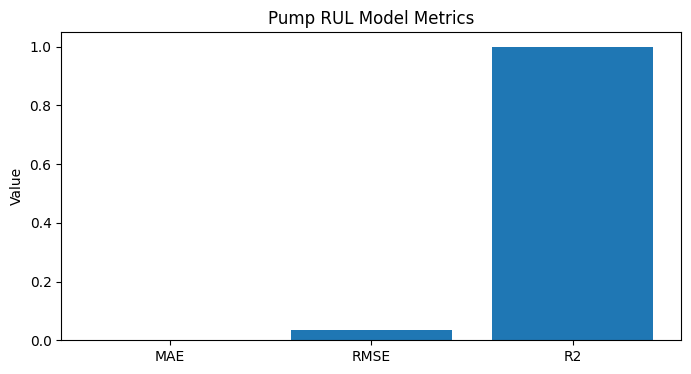

In [11]:
import matplotlib.pyplot as plt

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

plt.figure(figsize=(8,4))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title(
    "Pump RUL Model Metrics"
)

plt.ylabel("Value")

plt.show()

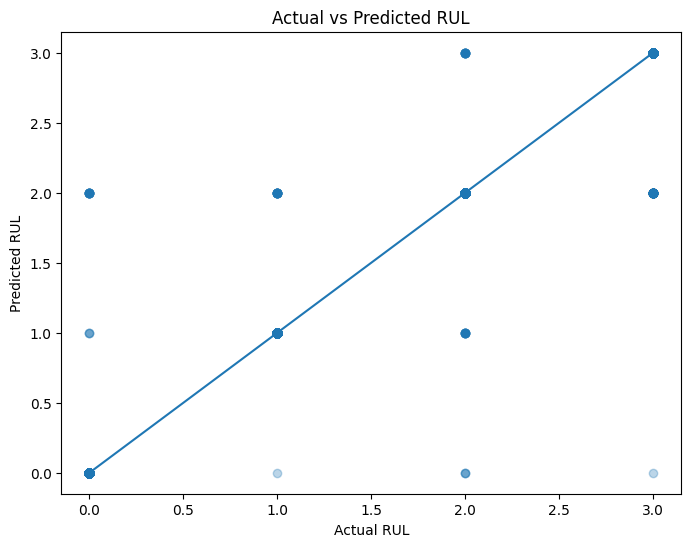

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.3
)

plt.xlabel(
    "Actual RUL"
)

plt.ylabel(
    "Predicted RUL"
)

plt.title(
    "Actual vs Predicted RUL"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

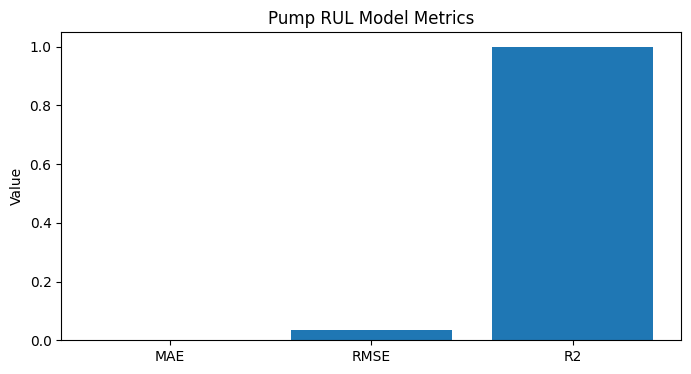

In [14]:
import matplotlib.pyplot as plt

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

plt.figure(figsize=(8,4))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title(
    "Pump RUL Model Metrics"
)

plt.ylabel("Value")

plt.show()

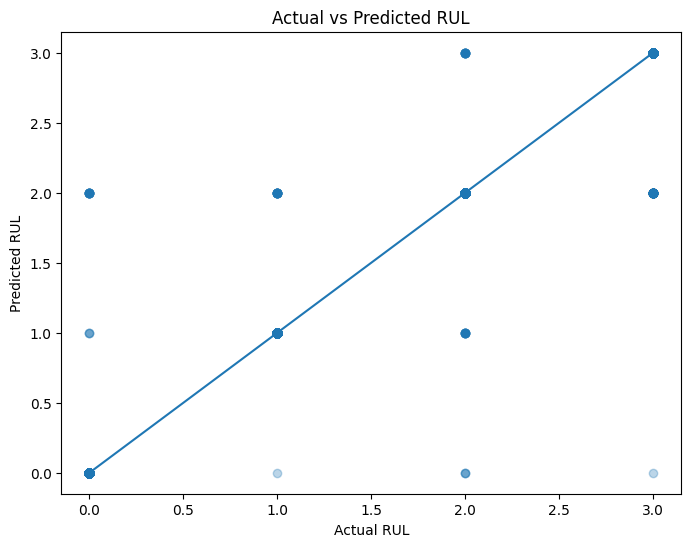

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.3
)

plt.xlabel(
    "Actual RUL"
)

plt.ylabel(
    "Predicted RUL"
)

plt.title(
    "Actual vs Predicted RUL"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [18]:
pred = failure_model.predict(X_test)

In [20]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    classification_report(
        y_test,
        pred
    )
)


              precision    recall  f1-score   support

           0       0.35      0.75      0.47     52056
           1       0.05      0.03      0.04     25886
           2       0.00      0.00      0.00     25891
           3       0.00      0.00      0.00     25767

    accuracy                           0.31    129600
   macro avg       0.10      0.20      0.13    129600
weighted avg       0.15      0.31      0.20    129600



c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

print(cm)

[[39146 12910     0     0]
 [25067   819     0     0]
 [25891     0     0     0]
 [23227  2540     0     0]]


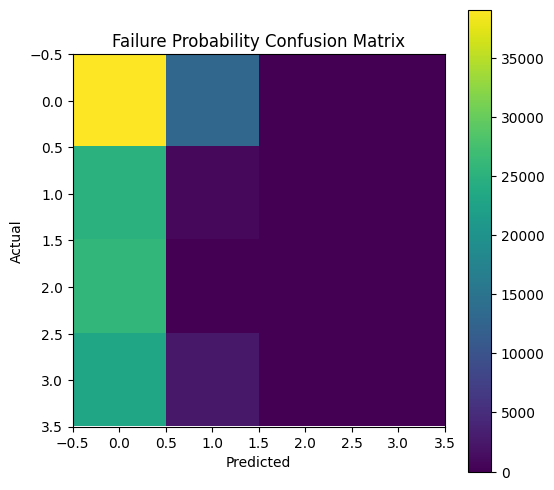

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title(
    "Failure Probability Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [26]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.35      0.75      0.47     52056
           1       0.05      0.03      0.04     25886
           2       0.00      0.00      0.00     25891
           3       0.00      0.00      0.00     25767

    accuracy                           0.31    129600
   macro avg       0.10      0.20      0.13    129600
weighted avg       0.15      0.31      0.20    129600



c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\CherukumpalemMohiddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

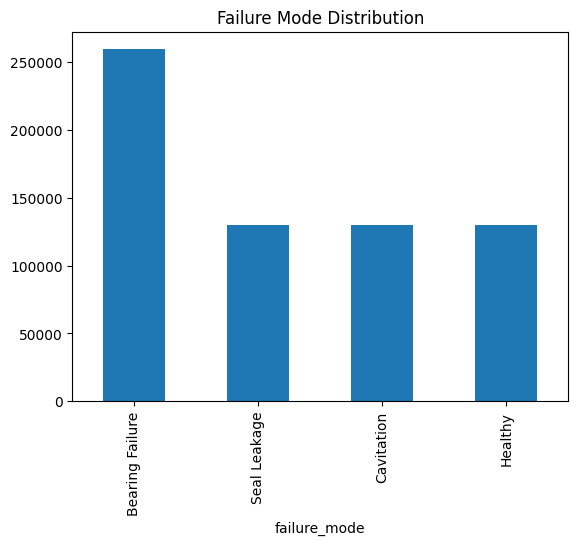

In [27]:
df["failure_mode"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Failure Mode Distribution"
)

plt.show()